In [1]:
!pip -q install openai-whisper librosa gradio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 25.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 5.9 MB/s eta 0:00:00


In [2]:
import whisper
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
import re

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

audio_file = next(iter(uploaded))

print("Uploaded file:", audio_file)

Saving App6.m4a to App6.m4a
Uploaded file: App6.m4a


In [5]:
model = whisper.load_model("base")

result = model.transcribe(audio_file)

transcript = result["text"]

print("TRANSCRIPT")
print("----------------")
print(transcript)

100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 80.9MiB/s]
/usr/local/lib/python3.13/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


TRANSCRIPT
----------------
 Hello, my name is Harsini. Only I am going to talk about artificial intelligence. Artificial intelligence is changing the way we work and learn.


In [6]:
# Load audio
audio, sample_rate = librosa.load(audio_file, sr=None)

# Calculate duration
duration = len(audio) / sample_rate

# Count words
word_count = len(transcript.split())

# Calculate words per minute
wpm = (word_count / duration) * 60

print("SPEECH ANALYSIS")
print("-------------------------")
print("Duration:", round(duration, 2), "seconds")
print("Word Count:", word_count)
print("Speaking Speed:", round(wpm, 2), "words per minute")

# Speaking speed feedback
if wpm < 100:
    feedback = "Your speaking pace is slow. Try speaking a little faster."
elif wpm <= 150:
    feedback = "Your speaking pace is good."
else:
    feedback = "Your speaking pace is fast. Try slowing down slightly."

print("Feedback:", feedback)

/tmp/ipykernel_2425/1039169415.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(audio_file, sr=None)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


SPEECH ANALYSIS
-------------------------
Duration: 11.75 seconds
Word Count: 24
Speaking Speed: 122.5 words per minute
Feedback: Your speaking pace is good.


In [7]:
# Filler word detection

filler_words = [
    "um", "uh", "like", "actually",
    "basically", "you know", "so"
]

text_lower = transcript.lower()

filler_counts = {}

for word in filler_words:
    pattern = r'\b' + re.escape(word) + r'\b'
    count = len(re.findall(pattern, text_lower))

    if count > 0:
        filler_counts[word] = count

total_fillers = sum(filler_counts.values())

print("FILLER WORD ANALYSIS")
print("-------------------------")

if filler_counts:
    for word, count in filler_counts.items():
        print(f"{word}: {count}")
else:
    print("No filler words detected.")

print("\nTotal filler words:", total_fillers)

FILLER WORD ANALYSIS
-------------------------
No filler words detected.

Total filler words: 0


In [8]:
# Presentation performance score

score = 100

# Speaking speed
if 100 <= wpm <= 150:
    speed_score = 25
elif 80 <= wpm < 100 or 150 < wpm <= 170:
    speed_score = 20
else:
    speed_score = 15

# Filler words
if total_fillers == 0:
    filler_score = 25
elif total_fillers <= 2:
    filler_score = 20
elif total_fillers <= 5:
    filler_score = 15
else:
    filler_score = 10

# Speech duration
if duration >= 30:
    duration_score = 25
else:
    duration_score = 20

# Word count
if word_count >= 50:
    word_score = 25
else:
    word_score = 20

score = speed_score + filler_score + duration_score + word_score

print("PRESENTATION PERFORMANCE")
print("-------------------------")
print("Speaking Speed Score:", speed_score, "/ 25")
print("Filler Word Score:", filler_score, "/ 25")
print("Duration Score:", duration_score, "/ 25")
print("Content Score:", word_score, "/ 25")
print("-------------------------")
print("Overall Score:", score, "/ 100")

if score >= 85:
    print("Performance: Excellent")
elif score >= 70:
    print("Performance: Good")
elif score >= 50:
    print("Performance: Needs Improvement")
else:
    print("Performance: Needs Significant Improvement")

PRESENTATION PERFORMANCE
-------------------------
Speaking Speed Score: 25 / 25
Filler Word Score: 25 / 25
Duration Score: 20 / 25
Content Score: 20 / 25
-------------------------
Overall Score: 90 / 100
Performance: Excellent


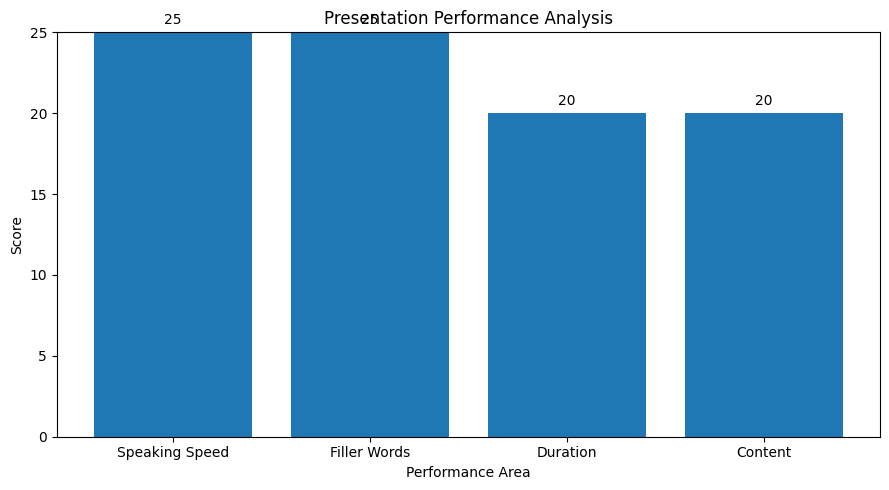

In [9]:
# Performance score visualization

categories = [
    "Speaking Speed",
    "Filler Words",
    "Duration",
    "Content"
]

scores = [
    speed_score,
    filler_score,
    duration_score,
    word_score
]

plt.figure(figsize=(9, 5))

plt.bar(categories, scores)

plt.ylim(0, 25)
plt.ylabel("Score")
plt.xlabel("Performance Area")
plt.title("Presentation Performance Analysis")

for i, value in enumerate(scores):
    plt.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

In [11]:
# Generate personalized feedback

feedback_points = []

# Speaking speed
if wpm < 100:
    feedback_points.append(
        "Your speaking speed is slow. Try speaking slightly faster."
    )
elif wpm <= 150:
    feedback_points.append(
        "Your speaking speed is good. Maintain this pace."
    )
else:
    feedback_points.append(
        "Your speaking speed is fast. Try slowing down slightly."
    )

# Filler words
if total_fillers == 0:
    feedback_points.append(
        "Excellent control of filler words. No unnecessary filler words detected."
    )
elif total_fillers <= 3:
    feedback_points.append(
        "You used a few filler words. Try reducing them further."
    )
else:
    feedback_points.append(
        "You used several filler words. Practice pausing instead of using filler words."
    )

# Duration
if duration < 30:
    feedback_points.append(
        "Your speech is quite short. Add more explanation and supporting points."
    )
else:
    feedback_points.append(
        "Your speech has a reasonable duration."
    )

# Content
if word_count < 50:
    feedback_points.append(
        "Your speech contains limited content. Try adding more details."
    )
else:
    feedback_points.append(
        "Your speech contains a good amount of content."
    )

print("PERSONALIZED PRESENTATION FEEDBACK")
print("-----------------------------------")

for i, feedback in enumerate(feedback_points, 1):
    print(f"{i}. {feedback}")

PERSONALIZED PRESENTATION FEEDBACK
-----------------------------------
1. Your speaking speed is good. Maintain this pace.
2. Excellent control of filler words. No unnecessary filler words detected.
3. Your speech is quite short. Add more explanation and supporting points.
4. Your speech contains limited content. Try adding more details.


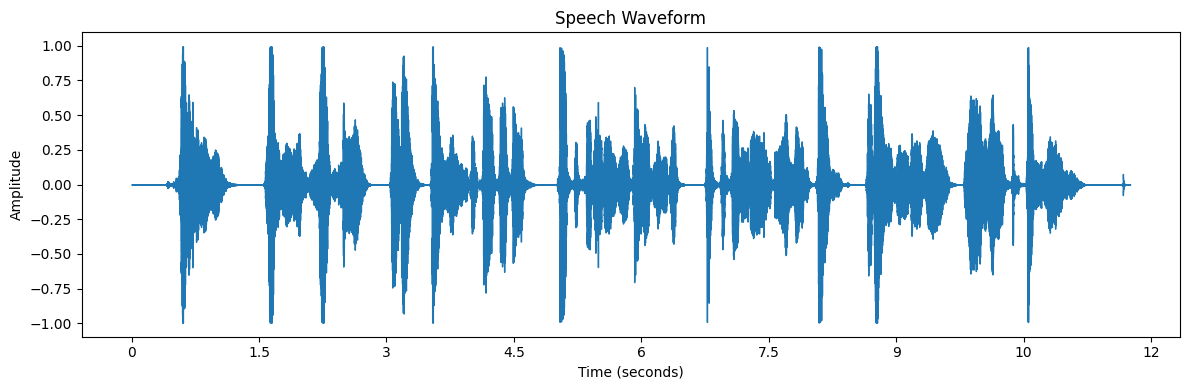

In [12]:
# Audio Waveform and Spectrogram

plt.figure(figsize=(12, 4))

librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Speech Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

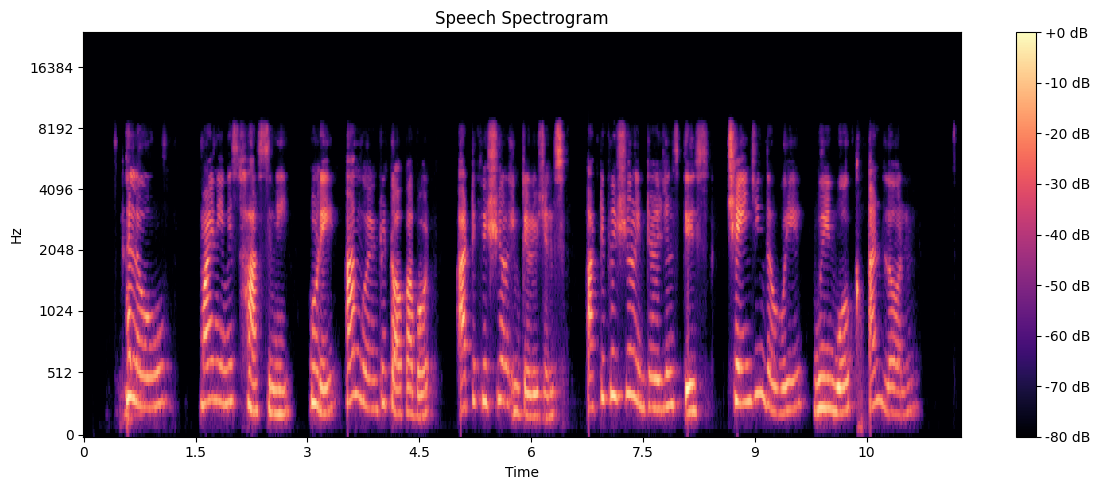

In [13]:
# Generate Spectrogram

spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate
)

spectrogram_db = librosa.power_to_db(
    spectrogram,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    spectrogram_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Speech Spectrogram")
plt.tight_layout()
plt.show()

In [14]:
# Final Presentation Analysis Report

print("=" * 50)
print("       AI VOICE PRESENTATION COACH")
print("=" * 50)

print("\nPRESENTATION METRICS")
print("-" * 50)
print(f"Speech Duration     : {duration:.2f} seconds")
print(f"Word Count          : {word_count}")
print(f"Speaking Speed      : {wpm:.2f} WPM")
print(f"Filler Words        : {total_fillers}")
print(f"Overall Score       : {score}/100")

print("\nPERFORMANCE")
print("-" * 50)

if score >= 85:
    performance = "Excellent"
elif score >= 70:
    performance = "Good"
elif score >= 50:
    performance = "Needs Improvement"
else:
    performance = "Needs Significant Improvement"

print(f"Overall Performance : {performance}")

print("\nPERSONALIZED FEEDBACK")
print("-" * 50)

for i, feedback in enumerate(feedback_points, 1):
    print(f"{i}. {feedback}")

print("\nTRANSCRIPT")
print("-" * 50)
print(transcript)

print("=" * 50)

       AI VOICE PRESENTATION COACH

PRESENTATION METRICS
--------------------------------------------------
Speech Duration     : 11.75 seconds
Word Count          : 24
Speaking Speed      : 122.50 WPM
Filler Words        : 0
Overall Score       : 90/100

PERFORMANCE
--------------------------------------------------
Overall Performance : Excellent

PERSONALIZED FEEDBACK
--------------------------------------------------
1. Your speaking speed is good. Maintain this pace.
2. Excellent control of filler words. No unnecessary filler words detected.
3. Your speech is quite short. Add more explanation and supporting points.
4. Your speech contains limited content. Try adding more details.

TRANSCRIPT
--------------------------------------------------
 Hello, my name is Harsini. Only I am going to talk about artificial intelligence. Artificial intelligence is changing the way we work and learn.


In [15]:
# AI Voice Presentation Coach - Gradio Interface

def analyze_presentation(audio_path):

    # Transcribe audio
    result = model.transcribe(audio_path)
    transcript = result["text"]

    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=None)

    # Duration
    duration = len(audio) / sample_rate

    # Word count
    word_count = len(transcript.split())

    # Speaking speed
    wpm = (word_count / duration) * 60

    # Filler words
    text_lower = transcript.lower()
    filler_counts = {}

    for word in filler_words:
        pattern = r'\b' + re.escape(word) + r'\b'
        count = len(re.findall(pattern, text_lower))

        if count > 0:
            filler_counts[word] = count

    total_fillers = sum(filler_counts.values())

    # Score
    if 100 <= wpm <= 150:
        speed_score = 25
    elif 80 <= wpm < 100 or 150 < wpm <= 170:
        speed_score = 20
    else:
        speed_score = 15

    if total_fillers == 0:
        filler_score = 25
    elif total_fillers <= 2:
        filler_score = 20
    elif total_fillers <= 5:
        filler_score = 15
    else:
        filler_score = 10

    duration_score = 25 if duration >= 30 else 20
    word_score = 25 if word_count >= 50 else 20

    score = speed_score + filler_score + duration_score + word_score

    # Performance
    if score >= 85:
        performance = "Excellent"
    elif score >= 70:
        performance = "Good"
    elif score >= 50:
        performance = "Needs Improvement"
    else:
        performance = "Needs Significant Improvement"

    # Feedback
    feedback = []

    if wpm < 100:
        feedback.append("Your speaking speed is slow. Try speaking slightly faster.")
    elif wpm <= 150:
        feedback.append("Your speaking speed is good. Maintain this pace.")
    else:
        feedback.append("Your speaking speed is fast. Try slowing down slightly.")

    if total_fillers == 0:
        feedback.append("Excellent control of filler words. No unnecessary filler words detected.")
    elif total_fillers <= 3:
        feedback.append("You used a few filler words. Try reducing them further.")
    else:
        feedback.append("You used several filler words. Practice pausing instead of using filler words.")

    if duration < 30:
        feedback.append("Your speech is quite short. Add more explanation and supporting points.")
    else:
        feedback.append("Your speech has a reasonable duration.")

    if word_count < 50:
        feedback.append("Your speech contains limited content. Try adding more details.")
    else:
        feedback.append("Your speech contains a good amount of content.")

    feedback_text = "\n".join(
        [f"{i}. {item}" for i, item in enumerate(feedback, 1)]
    )

    return (
        transcript,
        f"{duration:.2f} seconds",
        f"{word_count}",
        f"{wpm:.2f} WPM",
        f"{total_fillers}",
        f"{score}/100",
        performance,
        feedback_text
    )


# Create Gradio interface

interface = gr.Interface(
    fn=analyze_presentation,
    inputs=gr.Audio(
        sources=["upload"],
        type="filepath",
        label="Upload Your Presentation Audio"
    ),
    outputs=[
        gr.Textbox(label="Transcript"),
        gr.Textbox(label="Speech Duration"),
        gr.Textbox(label="Word Count"),
        gr.Textbox(label="Speaking Speed"),
        gr.Textbox(label="Filler Words"),
        gr.Textbox(label="Overall Score"),
        gr.Textbox(label="Performance"),
        gr.Textbox(label="Personalized Feedback")
    ],
    title="🎤 AI Voice-Based Presentation Coach",
    description="Upload your presentation audio and receive AI-powered speech analysis, scoring, and personalized feedback.",
    theme=gr.themes.Soft()
)

interface.launch()

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ba2fc17bd9f87ea9eb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
# Save Presentation Analysis to CSV

analysis_data = {
    "Speech Duration (seconds)": [round(duration, 2)],
    "Word Count": [word_count],
    "Speaking Speed (WPM)": [round(wpm, 2)],
    "Filler Words": [total_fillers],
    "Overall Score": [score],
    "Performance": [performance]
}

analysis_df = pd.DataFrame(analysis_data)

analysis_df.to_csv(
    "presentation_analysis.csv",
    index=False
)

print("Analysis saved successfully!")
print("\nSaved File: presentation_analysis.csv")
print("\nAnalysis Summary:")
display(analysis_df)

Analysis saved successfully!

Saved File: presentation_analysis.csv

Analysis Summary:


,Speech Duration (seconds),Word Count,Speaking Speed (WPM),Filler Words,Overall Score,Performance
0,11.75,24,122.5,0,90,Excellent


In [17]:
from google.colab import files

files.download("presentation_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Create README.md

readme_content = """
# AI Voice-Based Presentation Coach

An AI-powered presentation analysis tool that evaluates a speaker's voice recording and provides feedback on speaking performance.

## Features

- Speech-to-text transcription using Whisper
- Speech duration analysis
- Speaking speed calculation (Words Per Minute)
- Filler word detection
- Presentation performance scoring
- Personalized feedback
- Audio waveform visualization
- Speech spectrogram visualization
- Interactive Gradio interface
- CSV report generation

## Technologies Used

- Python
- OpenAI Whisper
- Librosa
- NLTK
- TextBlob
- Pandas
- NumPy
- Matplotlib
- Gradio

## How It Works

1. Upload a presentation audio recording.
2. Whisper converts speech into text.
3. The system calculates speech duration and speaking speed.
4. Filler words are detected from the transcript.
5. A presentation score is calculated.
6. Personalized feedback is generated.
7. Results can be saved as a CSV report.

## Performance Metrics

The system evaluates:

- Speaking Speed
- Filler Words
- Speech Duration
- Content Length

## Project Output

The application generates:

- Transcript
- Speech metrics
- Overall score
- Performance level
- Personalized improvement suggestions
- Audio visualizations
- CSV analysis report

## Author

Hasini Krishna
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!
